## SORRM Preliminary Analysis

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import mosaic
import geojson
import os
from xgcm import Grid
from datetime import datetime
from mpas_tools.ocean.depth import add_zmid
from mpas_tools.ocean.depth import compute_zmid
from mpas_tools.mesh.mask import compute_mpas_region_masks
from geometric_features import read_feature_collection

%load_ext autoreload
%autoreload 2
import mpasregions.sections as mps

In [2]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeMonthly' in i:
            new_name = i.replace('timeMonthly_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

def find_var_in_ds(ds, var_string):
    for i in ds.data_vars:
        if var_string in i:
            print(i)

def var_to_depth_coords(ds, variable):
    # target coords
    grid_nVertLevels = Grid(ds, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                                padding = 'extend', 
                                autoparse_metadata=False)
    
    # then transform the variable we are interested in to refBottomDepth
    depth_variable = grid_nVertLevels.transform(variable,
                               'Z',
                               target = ds.refBottomDepth,
                               method = 'linear',
                               target_data = ds.zMid)
    
    # then swap_dims to get refBottomDepth as a coordinate
    refBottomDepth_variable = depth_variable.swap_dims({'nVertLevels' : 'refBottomDepth' })

    return refBottomDepth_variable

def circular_polar_map():
    # Make the polar map circular
    theta = np.linspace(0, 2 * np.pi, 100)
    center = [0.5, 0.5]
    radius = 0.5
    
    verts = np.vstack([
        np.sin(theta) * radius + center[0],
        np.cos(theta) * radius + center[1]
    ]).T
    
    circle = mpath.Path(verts)
    return verts, circle

## An attempt to recreate transports calculated on E3SM 30-60km LR transect. Now use SORRM HR

From [this github notebook](https://github.com/kailauyeda/MPASO-WMTs/blob/generalize_transects/notebooks/restruc_data_compute_transports.ipynb)

In [3]:
sorrm_filepath = '/global/cfs/cdirs/m5260/kuyeda/20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter/run/'

# this is hist output
# which is snapshots?

# OPEN OCEAN AVG FILE
ocean_avg_ds_output = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpaso.hist.am.timeSeriesStatsMonthly.0200-01-01.nc')

# OPEN ICE AVG FILE
ice_avg_ds_output = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpassi.hist.am.timeSeriesStatsMonthly.0200-01-01.nc')

# select just the ice variables that we want
ice_avg_ds_output = ice_avg_ds_output[['timeMonthly_avg_iceAreaCell',
                                       'timeMonthly_avg_iceVolumeCell',
                                       'timeMonthly_avg_frazilFormation',
                                       'timeMonthly_avg_surfaceIceMelt',
                                       'timeMonthly_avg_basalIceMelt',
                                       'timeMonthly_avg_lateralIceMelt']]

# combine ice and ocean files into one dataset
avg_ds_output = xr.merge([ocean_avg_ds_output, ice_avg_ds_output])

# OPEN SNAPSHOTS OCEAN FILE
ss_ds_output = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpaso.hist.0200-02-01_00000.nc')

/tmp/ipykernel_2013092/3099355687.py:7: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ocean_avg_ds_output = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpaso.hist.am.timeSeriesStatsMonthly.0200-01-01.nc')
/tmp/ipykernel_2013092/3099355687.py:10: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it wi

In [4]:
# OPEN MESH & DS_OUTPUT FILES, FORMAT

# MESH (I.E., RESTART INITIAL CONDITION)
mesh = xr.open_dataset(sorrm_filepath + '20260520.v3.SORRME3r3.CRYO2010.bluepulse-control.chrysalis.mpaso.rst.0200-01-01_00000.nc')
# ice_mesh = xr.open_dataset(sorrm_filepath + '20260520.v3.SORRME3r3.CRYO2010.bluepulse-control.chrysalis.mpassi.rst.0200-01-01_00000.nc')

mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})


# set up descriptor for plotting 
# # set up mesh to apply polypcolor
mesh.attrs['is_periodic'] = 'YES'
mesh.attrs['x_period'] =  360
mesh.attrs['y_period'] = 0.0

# FORMAT AVG_DS_OUTPUT FILE
ds = mps.add_grid_info_coords(mesh,avg_ds_output)
ds['lonCell'] = ds.lonCell 
ds['lonEdge'] = ds.lonEdge
ds['lonVertex'] = ds.lonVertex 

# FORMAT AVG_DS_OUTPUT FROM SORRM 
drop_var_names = ['avgValue', 'Stats', 'min', 'max']

dropped_vars = [
    item for item in list(ds.data_vars)
    if any(var_name in item for var_name in drop_var_names)
]

ds = ds.drop_vars(dropped_vars)
new_name_dict = rename_time_avg_vars(ds)
ds = ds.rename(new_name_dict)

ds_grid = Grid(ds, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
           padding = 'extend', 
           autoparse_metadata = False)

ds['chiPhyVerTemp_center'] = ds_grid.interp(ds.chiPhyVerTemp, 'Z' , padding = 'extend')
ds['chiPhyVerSalt_center'] = ds_grid.interp(ds.chiPhyVerSalt, 'Z', padding = 'extend')
ds['vertDiff_center'] = ds_grid.interp(ds.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
ds['salinity'] = ds.salinity.ffill(dim= 'nVertLevels', limit = 2)
ds['salinity'] = ds.salinity.bfill(dim= 'nVertLevels', limit = 2)

ds['salinity_P1'] = ds_grid.interp(ds.salinity, 'Z', padding = 'extend')

# add depth datavariable
ds['zMid'] = - compute_zmid(ds.bottomDepth, ds.maxLevelCell, ds.layerThickness)

# create a grid for interpolation & transformation
grid_nVertLevels = Grid(ds, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                                padding = 'extend', 
                                autoparse_metadata=False)

# add a zEdge variable
ds['z_P1'] = grid_nVertLevels.interp(ds.zMid, 'Z', padding = 'extend')
ds['z_P1'] = ds.z_P1.transpose('Time','nCells','nVertLevelsP1')
ds['z_P1'][:,:,0] = ds.z_P1[:,:,0] - ((ds.z_P1[:,:,1] - ds.z_P1[:,:,0])/2)
ds['z_P1'][:,:,-1] = ds.z_P1[:,:,-1] + ((ds.z_P1[:,:,-1] - ds.z_P1[:,:,-2])/2)

# ^^ have to manually add the first and last points, since they should extend beyond the zMid points 

# add a refBottomDepth variable that sits on nVertLevels
ds['refBottomDepth_P1'] = grid_nVertLevels.interp(ds.refBottomDepth, 'Z', padding = 'extend')
ds['refBottomDepth_P1'][0] = ds.refBottomDepth_P1[0] - ((ds.refBottomDepth_P1[1] - ds.refBottomDepth_P1[0])/2)
ds['refBottomDepth_P1'][-1] = ds.refBottomDepth_P1[-1] - ((ds.refBottomDepth_P1[-1] - ds.refBottomDepth_P1[-2])/2)

ds = ds.assign_coords({'refBottomDepth' : ds.refBottomDepth, 'refBottomDepth_P1' : ds.refBottomDepth_P1})

# SET UP PLOTTING
# set up plotting descriptor
projection = ccrs.PlateCarree(central_longitude = 180)
descriptor = mosaic.Descriptor(mesh, projection, transform = ccrs.PlateCarree(), use_latlon=True)

# set up stereographic projections
stereo_projection = ccrs.SouthPolarStereo()
stereo_transform = ccrs.PlateCarree()
stereo_descriptor = mosaic.Descriptor(mesh, stereo_projection, stereo_transform)

"""
# FORMAT SNAPSHOTS FROM SORRM
# 9/2/26 --> currently commented out b/c no salinity datavariable
# snapshots at every timestep (dt = ? mins)
# ss_ds_output = xr.open_dataset(filepath + f'{sim_res}_channel_output.nc' + suffix,decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
ss_ds_output['salinity'] = ss_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', padding = 'extend')
""";

In [5]:
ds_refbd = ds.swap_dims({'nVertLevels' : 'refBottomDepth', 'nVertLevelsP1' : 'refBottomDepth_P1'})

ds_refbd_grid = Grid(ds_refbd,
                     coords = {'Z' : {'center' : 'refBottomDepth', 'outer' : 'refBottomDepth_P1'}},
                     padding = 'extend',
                     autoparse_metadata = False)

In [6]:
ds_grid

<xgcm.Grid>
Z Axis (not periodic, padding='extend'):
  * center   nVertLevels --> outer
  * outer    nVertLevelsP1 --> center

In [7]:
ds_refbd_grid

<xgcm.Grid>
Z Axis (not periodic, padding='extend'):
  * center   refBottomDepth --> outer
  * outer    refBottomDepth_P1 --> center

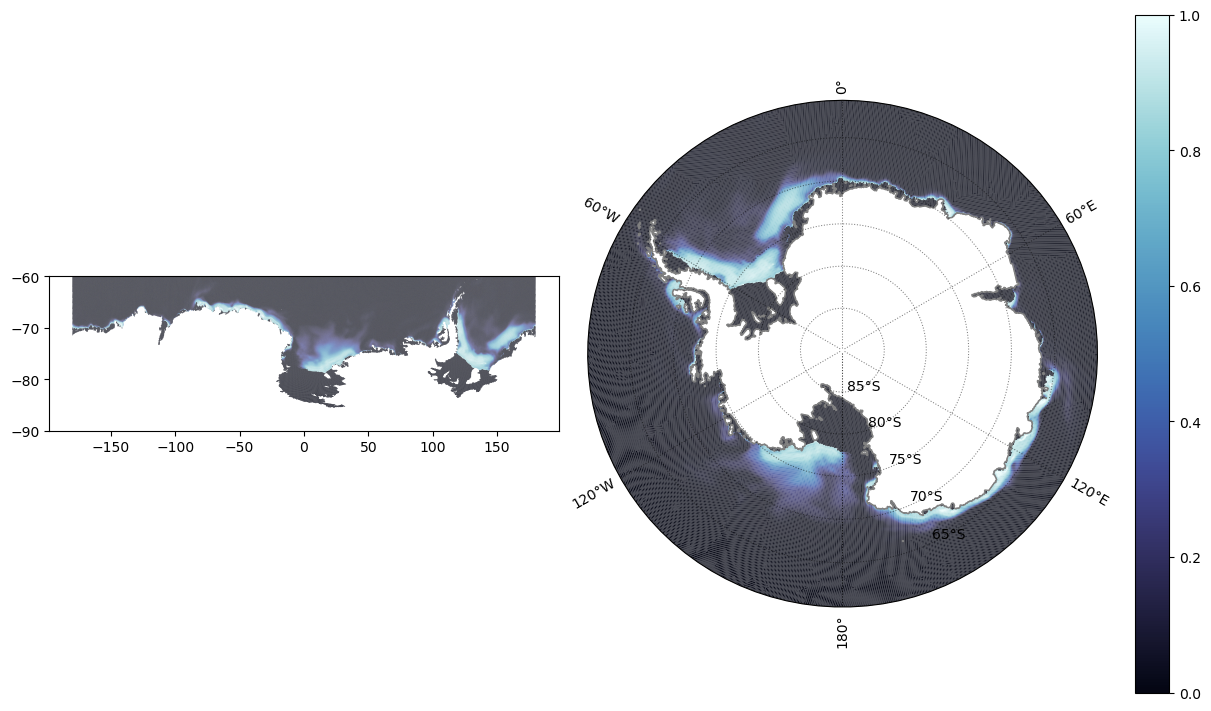

In [8]:
fig = plt.figure(constrained_layout = True, figsize = (12,7))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)

# LHS, default mercator on cartersian axis
mosaic.polypcolor(ax1, descriptor, ds.iceAreaCell, cmap = 'cmo.ice', vmin=0, vmax=1)
ax1.set_ylim(-90,-60)
ax1.set_aspect(4)

# RHS, polar-stereographic
stereo_projection = ccrs.SouthPolarStereo()
stereo_transform = ccrs.PlateCarree()

c = mosaic.polypcolor(ax2, stereo_descriptor, ds.iceAreaCell, cmap  = 'cmo.ice', vmin=0, vmax=1)
mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
ax2.set_extent([-180, 180, -90, -60],
                 crs = ccrs.PlateCarree())

verts, circle = circular_polar_map()

ax2.set_boundary(circle, transform=ax2.transAxes)
gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)
fig.colorbar(c, ax=ax2, orientation = 'vertical')

In [9]:
def plot_stereo(data_variable, cmap_choice = 'cmo.matter'):
    stereo_projection = ccrs.SouthPolarStereo()
    stereo_transform = ccrs.PlateCarree()
    stereo_descriptor = mosaic.Descriptor(mesh, stereo_projection, stereo_transform)
    
    fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True, subplot_kw={'projection' : stereo_projection})
    
    c = mosaic.polypcolor(ax, stereo_descriptor, data_variable, cmap = cmap_choice)
    mosaic.coastlines(ax, stereo_descriptor, color = 'gray')
    
    # Focus on Southern Ocean
    ax.set_extent(
        [-180, 180, -90, -30],
        crs=ccrs.PlateCarree()
    )
    # Make the polar map circular
    theta = np.linspace(0, 2 * np.pi, 100)
    center = [0.5, 0.5]
    radius = 0.5
    
    verts = np.vstack([
        np.sin(theta) * radius + center[0],
        np.cos(theta) * radius + center[1]
    ]).T
    
    circle = mpath.Path(verts)
    
    ax.set_boundary(circle, transform=ax.transAxes)
    gl = ax.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

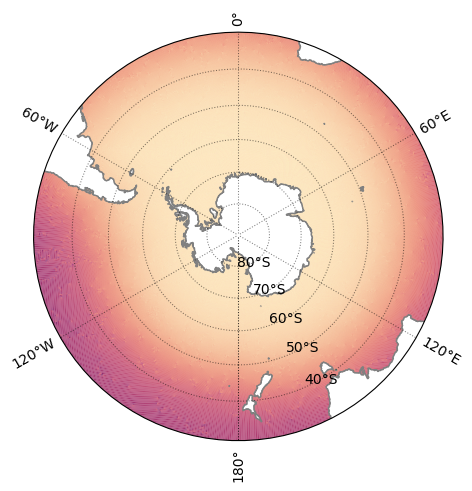

In [10]:
plot_stereo(ds.areaCell)
# ax.scatter(np.rad2deg(ds_transect_edges.lonEdge)-180, np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
#            c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r')

## Exploratory transect analysis

### Drake Passage transect

In [11]:
# path = './'
# filename = 'Drake_Passage_SORRM_HR_test12'
# geojson_file_name = 'SORRM HR Drake Passage Region'
# tags = 'Southern Ocean'
# author = 'Kaila Uyeda'

# lons = np.array([294, 292, 295])
# lats = np.array([-67,-55, -55])

# # ==========================
# # These 3 functions are part of the open_transect_from_alg(ds, lats, lons, path, filename, geojson_file_name, tags, author) function

# test_edges, test_verts = mps.calculate_transects_multiple_pts(lons, lats, ds)

# test_verts_lats, test_verts_lons, dsMasks = mps.transect_from_alg_create_nc(test_verts, 
#                                                                                 ds, 
#                                                                                 path,
#                                                                                 filename, 
#                                                                                 geojson_file_name,
#                                                                                 tags, 
#                                                                                 author)

# alg_edges, alg_vertices = mps.find_and_sort_transect_edges_and_vertices(ds,dsMasks)

# # ==========================
# edges = alg_edges
# vertices = alg_vertices
# mask = dsMasks

# # ==========================

# ds_transect_edges_nCells, ds_transect_edges = mps.format_transect_data(ds, edges)
# print('calculate_velo_into_mask')
# ds_transect_edges = mps.calculate_velo_into_mask(ds_transect_edges, ds, mask, edges, datavariable= 'normalVelocity')
# print('calculate_transport_into_mask')
# ds_transect_edges = mps.calculate_transport_into_mask(ds_transect_edges)

# dsMasks = xr.open_dataset(f'./{filename}_transect_from_alg.nc')

In [12]:
# fig = plt.figure(constrained_layout = True, figsize = (12,7))
# ax1 = fig.add_subplot(1, 2, 1)
# ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
# mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# # LHS, default mercator on cartersian axis
# mosaic.polypcolor(ax1, descriptor, mask, cmap = 'cool')
# ax1.scatter(np.rad2deg(ds_transect_edges.lonEdge)-180, np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
#            c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r')
# ax1.set_ylim(-75,-50)
# ax1.set_xlim(100,130)

# # RHS, polar-stereographic
# stereo_projection = ccrs.SouthPolarStereo()
# stereo_transform = ccrs.PlateCarree()

# c = mosaic.polypcolor(ax2, stereo_descriptor, mask, cmap  = 'cool')
# mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
# ax2.scatter(np.rad2deg(ds_transect_edges.lonEdge), np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
#        c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r', transform = ccrs.PlateCarree())
# ax2.set_extent([-180, 180, -90, -40],
#                  crs = ccrs.PlateCarree())

# verts, circle = circular_polar_map()

# ax2.set_boundary(circle, transform=ax2.transAxes)
# gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

In [13]:
# ds_te_chiSpurSalt = ds_transect_edges.chiSpurSaltBR08.where(ds_transect_edges.maxLevelCell > ds_transect_edges.nVertLevels)

In [14]:
# fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

# mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# mosaic.polypcolor(ax, descriptor, mask, cmap='cool')
# a = ax.scatter(np.rad2deg(ds_transect_edges.lonEdge)-180, np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
#            c = ds_te_chiSpurSalt.isel(Time=0).mean(dim='TWO').sum(dim='nVertLevels'), cmap='RdBu_r')

# ax.set_ylim(-75,-50)
# ax.set_xlim(100,130)
# fig.colorbar(a, ax=ax)

In [15]:
# fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

# mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# mosaic.polypcolor(ax, descriptor, mask, cmap='cool')


# # attempt to find just a single transect
# ds_single_transect = ds_transect_edges.isel(nEdges = slice(0,203), Time=0)
# ds_single_transect_masked = ds_single_transect.where(ds_single_transect.maxLevelCell > ds_single_transect.nVertLevels)

# a = ax.scatter(np.rad2deg(ds_single_transect.lonEdge)-180, np.rad2deg(ds_single_transect.latEdge), marker = '.',
#               c = ds_single_transect.transect_edgesOrdered)

# ax.set_ylim(-70,-50)
# ax.set_xlim(100,130)
# fig.colorbar(a, ax=ax)

In [16]:
# fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7))

# ds_single_transect_masked.chiPhyVerTemp_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[0,0],y='nVertLevels',vmin=-1e-5, vmax=1e-5, cmap='RdBu_r')
# ds_single_transect_masked.chiSpurTempBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[0,1],y='nVertLevels',vmin=-1e-5, vmax=1e-5, cmap='RdBu_r')

# ds_single_transect_masked.chiPhyVerSalt_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[1,0],y='nVertLevels',vmin=-1e-6, vmax=1e-6, cmap='RdBu_r')
# ds_single_transect_masked.chiSpurSaltBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[1,1],y='nVertLevels',vmin=-1e-5, vmax=1e-5, cmap='RdBu_r')

# titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

# for i in range(0,2):
#     for j in range(0,2):
#         ax[i,j].invert_yaxis()
#         ax[i,j].set_title(titles[i][j])

# fig.suptitle('Mixing along Drake Passage Transect')

## Ross Sea Shelf Break (continental slope flows)
**Problem with .geojson b/c crosses anti-meridian. This is something that *can* be fixed, but I am not inclined to address this problem atm (9/8/26)**
>- transect D in the Amblas & Dowdeswell paper

In [17]:
# path = './'
# filename = 'Ross_Sea_Slope_SORRM_HR_test0'
# geojson_file_name = 'SORRM HR Ross Sea Region'
# tags = 'Southern Ocean'
# author = 'Kaila Uyeda'


# # lons = np.array([200, 180, 180])
# # lats = np.array([-85,-80, -75])

# lons = np.array([10, -5, 10, 20]) + 180
# lats = np.array([-85, -82.5, -72.5, -70]) 

# # ==========================
# # These 3 functions are part of the open_transect_from_alg(ds, lats, lons, path, filename, geojson_file_name, tags, author) function

# test_edges, test_verts = mps.calculate_transects_multiple_pts(lons, lats, ds)

# test_verts_lats, test_verts_lons, dsMasks = mps.transect_from_alg_create_nc(test_verts, 
#                                                                                 ds, 
#                                                                                 path,
#                                                                                 filename, 
#                                                                                 geojson_file_name,
#                                                                                 tags, 
#                                                                                 author)

# alg_edges, alg_vertices = mps.find_and_sort_transect_edges_and_vertices(ds,dsMasks)

# # ==========================
# edges = alg_edges
# vertices = alg_vertices
# mask = dsMasks

# # ==========================

# ds_transect_edges_nCells, ds_transect_edges = mps.format_transect_data(ds, edges)
# print('calculate_velo_into_mask')
# ds_transect_edges = mps.calculate_velo_into_mask(ds_transect_edges, ds, mask, edges, datavariable= 'normalVelocity')
# print('calculate_transport_into_mask')
# ds_transect_edges = mps.calculate_transport_into_mask(ds_transect_edges)

# dsMasks = xr.open_dataset(f'./{filename}_transect_from_alg.nc')

In [18]:
# # check if the transect/mask looks corect
# fig = plt.figure(constrained_layout = True, figsize = (12,7))
# ax1 = fig.add_subplot(1, 2, 1)
# ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
# mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# # LHS, default mercator on cartersian axis
# c = mosaic.polypcolor(ax1, descriptor, mesh.areaCell)
# ax1.scatter(np.rad2deg(ds.isel(nEdges = alg_edges).lonEdge)-180, np.rad2deg(ds.isel(nEdges = alg_edges).latEdge), marker = '.', )
# ax1.set_xlim(-30,30)
# ax1.set_ylim(-90,-65)

# # RHS, polar-stereographic
# stereo_projection = ccrs.SouthPolarStereo()
# stereo_transform = ccrs.PlateCarree()

# mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
# ax2.scatter(np.rad2deg(ds.isel(nEdges = alg_edges).lonEdge), np.rad2deg(ds.isel(nEdges = alg_edges).latEdge), marker = '.', transform = ccrs.PlateCarree())
# ax2.set_extent([-180, 180, -90, -65],
#                  crs = ccrs.PlateCarree())

# verts, circle = circular_polar_map()

# ax2.set_boundary(circle, transform=ax2.transAxes)
# gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

In [19]:
# # check if the transect/mask looks corect
# fig = plt.figure(constrained_layout = True, figsize = (12,7))
# ax1 = fig.add_subplot(1, 2, 1)
# ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
# mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# # LHS, default mercator on cartersian axis
# c = mosaic.polypcolor(ax1, descriptor, mesh.areaCell)
# ax1.scatter(np.rad2deg(ds.isel(nEdges = test_edges).lonEdge)-180, np.rad2deg(ds.isel(nEdges = test_edges).latEdge), marker = '.', )
# ax1.set_xlim(-30,30)
# ax1.set_ylim(-90,-70)

# # RHS, polar-stereographic
# stereo_projection = ccrs.SouthPolarStereo()
# stereo_transform = ccrs.PlateCarree()

# mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
# ax2.scatter(np.rad2deg(ds.isel(nEdges = test_edges).lonEdge), np.rad2deg(ds.isel(nEdges = test_edges).latEdge), marker = '.', transform = ccrs.PlateCarree())
# ax2.set_extent([-180, 180, -90, -40],
#                  crs = ccrs.PlateCarree())

# verts, circle = circular_polar_map()

# ax2.set_boundary(circle, transform=ax2.transAxes)
# gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

## Amundsen Sea Shelf
>- Transect F in the Amblas & Dowdeswell paper

In [20]:
path = './'
filename = 'Amundsen_Sea_Slope_SORRM_HR_test0'
geojson_file_name = 'SORRM HR Ross Sea Region'
tags = 'Southern Ocean'
author = 'Kaila Uyeda'


# lons = np.array([200, 180, 180])
# lats = np.array([-85,-80, -75])

lons = np.array([78, 75, 70, 69, 67]) + 180
lats = np.array([-77, -75, -73, -70, -70]) 

# ==========================
# These 3 functions are part of the open_transect_from_alg(ds, lats, lons, path, filename, geojson_file_name, tags, author) function

test_edges, test_verts = mps.calculate_transects_multiple_pts(lons, lats, ds)

test_verts_lats, test_verts_lons, dsMasks = mps.transect_from_alg_create_nc(test_verts, 
                                                                                ds, 
                                                                                path,
                                                                                filename, 
                                                                                geojson_file_name,
                                                                                tags, 
                                                                                author)

alg_edges, alg_vertices = mps.find_and_sort_transect_edges_and_vertices(ds,dsMasks)

# ==========================
edges = alg_edges
vertices = alg_vertices
mask = dsMasks

# ==========================

ds_transect_edges_nCells, ds_transect_edges = mps.format_transect_data(ds, edges)
print('calculate_velo_into_mask')
ds_transect_edges = mps.calculate_velo_into_mask(ds_transect_edges, ds, mask, edges, datavariable= 'normalVelocity')
print('calculate_transport_into_mask')
ds_transect_edges = mps.calculate_transport_into_mask(ds_transect_edges)

dsMasks = xr.open_dataset(f'./{filename}_transect_from_alg.nc')

broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
Amundsen_Sea_Slope_SORRM_HR_test0_transect_from_alg.geojson exists!
Opening Amundsen_Sea_Slope_SORRM_HR_test0_transect_from_alg.nc as dsMasks
switching transects at  6
calculate_velo_into_mask
calculate_transport_into_mask


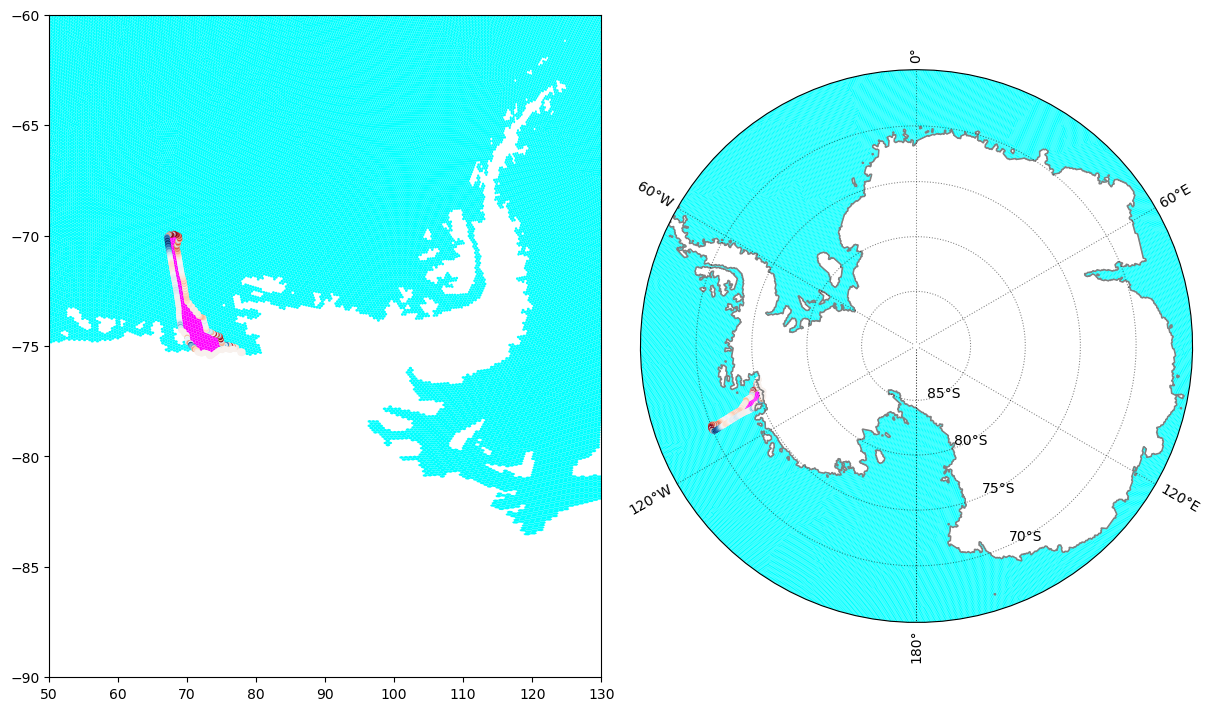

In [21]:
fig = plt.figure(constrained_layout = True, figsize = (12,7))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# LHS, default mercator on cartersian axis
mosaic.polypcolor(ax1, descriptor, mask, cmap = 'cool')
ax1.scatter(np.rad2deg(ds_transect_edges.lonEdge)-180, np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
           c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r')
ax1.set_xlim(50,130)
ax1.set_ylim(-90,-60)

# RHS, polar-stereographic
stereo_projection = ccrs.SouthPolarStereo()
stereo_transform = ccrs.PlateCarree()

c = mosaic.polypcolor(ax2, stereo_descriptor, mask, cmap  = 'cool')
mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
ax2.scatter(np.rad2deg(ds_transect_edges.lonEdge), np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
       c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r', transform = ccrs.PlateCarree())
ax2.set_extent([-180, 180, -90, -65],
                 crs = ccrs.PlateCarree())

verts, circle = circular_polar_map()

ax2.set_boundary(circle, transform=ax2.transAxes)
gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

Text(0.5, 0.98, 'Amundsen Sea Ice Shelf Transect \n F transect; austral summer (Jan)')

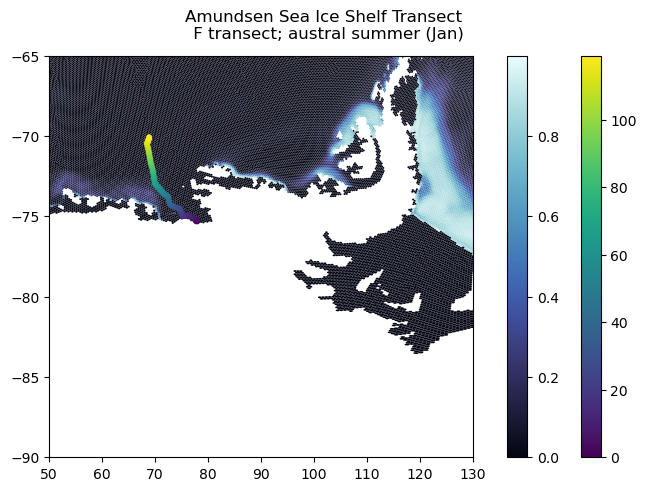

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

mask = dsMasks.regionCellMasks.isel(nRegions = 0)

c = mosaic.polypcolor(ax, descriptor, ds.iceAreaCell, cmap='cmo.ice')


# attempt to find just a single transect
ds_single_transect = ds_transect_edges.isel(nEdges = slice(0,120), Time=0)
ds_single_transect_masked = ds_single_transect.where(ds_single_transect.maxLevelCell > ds_single_transect.nVertLevels)

a = ax.scatter(np.rad2deg(ds_single_transect.lonEdge)-180, np.rad2deg(ds_single_transect.latEdge), marker = '.',
              c = ds_single_transect.transect_edgesOrdered)

ax.set_xlim(50,130)
ax.set_ylim(-90,-65)

fig.colorbar(a, ax=ax)
fig.colorbar(c, ax=ax)
fig.suptitle('Amundsen Sea Ice Shelf Transect \n F transect; austral summer (Jan)')

Text(0.5, 0.98, 'Mixing along Amundsen Sea Ice Shelf \n nVertLevels ; F transect')

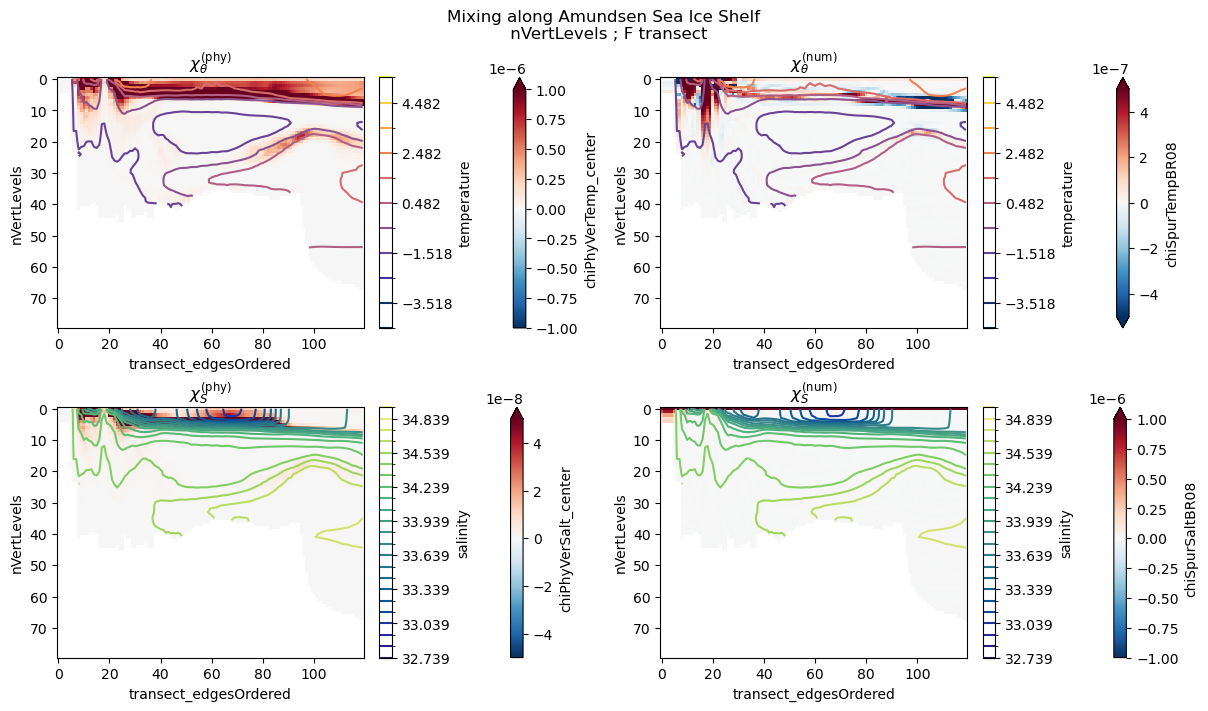

In [23]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7))

# TEMPERATURE 

# interpolate to get target_coords
ds_single_transect_masked['temperature_P1'] = grid_nVertLevels.interp(ds_single_transect_masked.temperature, 'Z', padding = 'extend')

# + 3 * target_coord_spacing to ensure that the upper and lower bins have a Gphy = 0

target_T_coord_spacing = 1

lower_bound = ds_single_transect_masked.temperature_P1.min() - (3 * target_T_coord_spacing)
upper_bound = ds_single_transect_masked.temperature_P1.max() + (3 * target_T_coord_spacing)

target_T_coords_P1 = np.arange(lower_bound,upper_bound,target_T_coord_spacing)
dlambda_T = target_T_coords_P1[0] - target_T_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_T_coords = (target_T_coords_P1[1:] + target_T_coords_P1[:-1]) / 2

### 

ds_single_transect_masked.chiPhyVerTemp_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[0,0],
                                                                                                                    vmin = -1e-6,
                                                                                                                    vmax = 1e-6,
                                                                                                                    y='nVertLevels', 
                                                                                                                    cmap='RdBu_r')
ds_single_transect_masked.chiSpurTempBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[0,1],
                                                                                                               vmin = -5e-7,
                                                                                                               vmax = 5e-7,
                                                                                                               y='nVertLevels', 
                                                                                                               cmap='RdBu_r')

ds_single_transect_masked.temperature.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[0,0],
                                                                                                                   y='nVertLevels',
                                                                                                                   levels = target_T_coords, 
                                                                                                                   add_colorbar=True,
                                                                                                                   cmap = 'cmo.thermal')

ds_single_transect_masked.temperature.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[0,1],
                                                                                                                   y='nVertLevels',
                                                                                                                   levels = target_T_coords, 
                                                                                                                   add_colorbar=True,
                                                                                                                   cmap = 'cmo.thermal')

# SALINITY
# define target_coords

target_coord_spacing = 0.1
ds_single_transect_masked['salinity_P1'] = grid_nVertLevels.interp(ds_single_transect_masked.salinity, 'Z', padding = 'extend')

# +2 to ensure that the upper and lower bins have a Gphy = 0
# lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
# upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2

lower_bound = ds_single_transect_masked.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_single_transect_masked.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

ds_single_transect_masked.chiPhyVerSalt_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[1,0],
                                                                                                                    vmin = -5e-8,
                                                                                                                    vmax = 5e-8,
                                                                                                                    y='nVertLevels', 
                                                                                                                    cmap='RdBu_r')
ds_single_transect_masked.chiSpurSaltBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[1,1],
                                                                                                               vmin = -1e-6,
                                                                                                               vmax = 1e-6,
                                                                                                               y='nVertLevels', 
                                                                                                               cmap='RdBu_r')

ds_single_transect_masked.salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[1,0],
                                                                                                                y='nVertLevels',
                                                                                                                levels = target_coords, 
                                                                                                                add_colorbar=True,
                                                                                                                cmap = 'cmo.haline')
ds_single_transect_masked.salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[1,1],
                                                                                                                y='nVertLevels',
                                                                                                                levels = target_coords, 
                                                                                                                add_colorbar=True,
                                                                                                                cmap = 'cmo.haline')


titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]


for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_title(titles[i][j])
        ax[i,j].invert_yaxis()

fig.suptitle('Mixing along Amundsen Sea Ice Shelf \n nVertLevels ; F transect')

In [24]:
# remap this into chi into salinity coordinates
# transform chi onto salinity surfaces
# target coords
grid_nVertLevels = Grid(ds_single_transect_masked, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
ds_single_transect_masked['salinity_P1'] = grid_nVertLevels.interp(ds_single_transect_masked.salinity, 'Z', padding = 'extend')

# + 3 * target_coord_spacing to ensure that the upper and lower bins have a Gphy = 0

target_coord_spacing = 0.1

lower_bound = ds_single_transect_masked.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_single_transect_masked.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

# transform chi onto salinity coordinates
# chi is in units of degC^2 / s, which is linear and intensive (not volume-weighted)

chi_ds = ds_single_transect_masked[['chiPhyVerTemp_center','chiSpurTempBR08','chiPhyVerSalt_center','chiSpurSaltBR08']]
chi_ds = chi_ds.where(chi_ds.nVertLevels < ds_single_transect_masked.maxLevelCell) # apply a mask to remove inf values

# temperature mixing
chiPhyVerTemp_center_salinity = grid_nVertLevels.transform(chi_ds.chiPhyVerTemp_center,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)

chiSpurTempBR08_salinity = grid_nVertLevels.transform(chi_ds.chiSpurTempBR08,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)

chiPhyVerSalt_center_salinity = grid_nVertLevels.transform(chi_ds.chiPhyVerSalt_center,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)

chiSpurSaltBR08_salinity = grid_nVertLevels.transform(chi_ds.chiSpurSaltBR08,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)


/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)


Text(0.5, 0.98, 'Mixing along Amundsen Sea Ice Shelf (Weddell Sea) Transect \n salinity ; F transect')

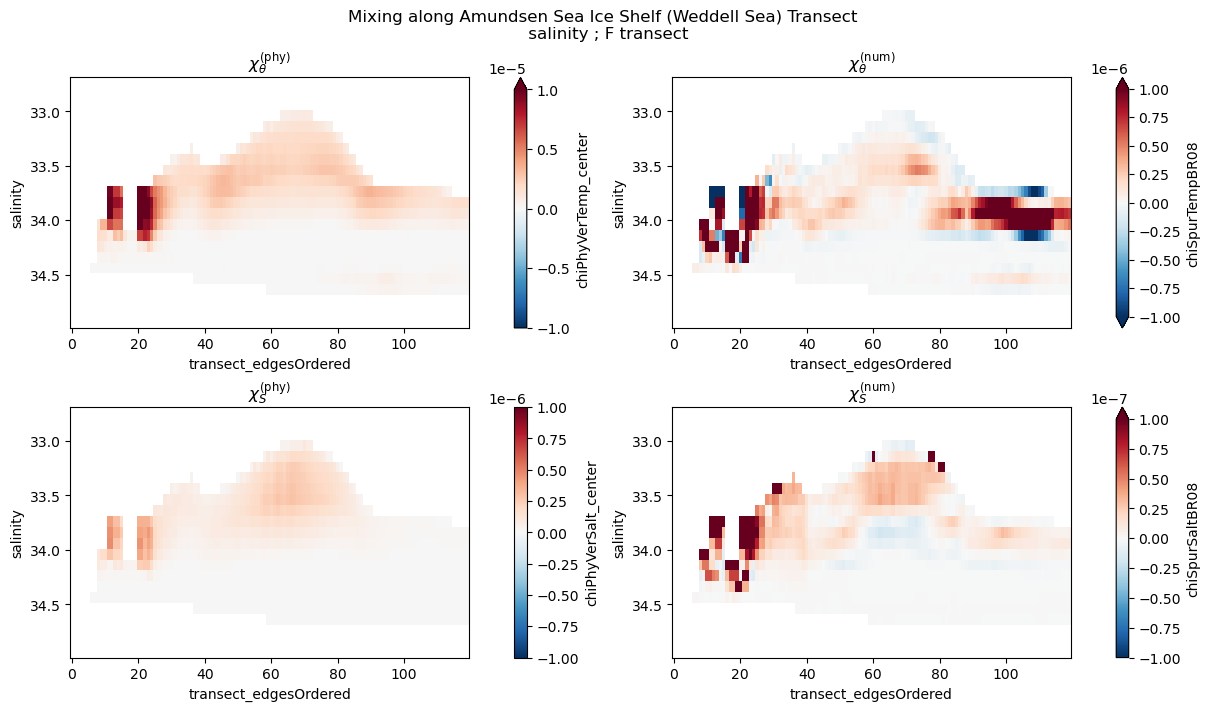

In [25]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize = (12,7))

# TEMPERATURE (note that this is plotted in salinity space)
chiPhyVerTemp_center_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,0], 
                                                                                                   vmin = -1e-5,
                                                                                                   vmax = 1e-5,
                                                                                                   y='salinity',
                                                                                                   cmap = 'RdBu_r')
chiSpurTempBR08_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,1], 
                                                                                              vmin = -1e-6,
                                                                                              vmax = 1e-6, 
                                                                                              y='salinity',
                                                                                              cmap = 'RdBu_r')

# SALINITY
chiPhyVerSalt_center_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,0], 
                                                                                                   vmin = -1e-6,
                                                                                                   vmax = 1e-6, 
                                                                                                   y='salinity',
                                                                                                   cmap = 'RdBu_r')
chiSpurSaltBR08_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,1], 
                                                                                              vmin = -1e-7,
                                                                                              vmax = 1e-7,
                                                                                              y='salinity',
                                                                                              cmap = 'RdBu_r')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()
        ax[i,j].set_title(titles[i][j])

fig.suptitle('Mixing along Amundsen Sea Ice Shelf (Weddell Sea) Transect \n salinity ; F transect')


In [26]:
# plot in depth coords
refBottomDepth_chiSpurSaltBR08 = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiSpurSaltBR08, chosen_method = 'linear').to_dataset(name = 'chiSpurSaltBR08')
refBottomDepth_chiPhyVerSalt_center = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiPhyVerSalt_center, chosen_method = 'linear').to_dataset(name = 'chiPhyVerSalt_center')
refBottomDepth_chiSpurTempBR08 = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiSpurTempBR08, chosen_method = 'linear').to_dataset(name = 'chiSpurTempBR08')
refBottomDepth_chiPhyVerTemp_center = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiPhyVerTemp_center, chosen_method = 'linear').to_dataset(name = 'chiPhyVerTemp_center')
refBottomDepth_chi_ds = xr.merge([refBottomDepth_chiSpurSaltBR08, refBottomDepth_chiPhyVerSalt_center, refBottomDepth_chiSpurTempBR08, refBottomDepth_chiPhyVerTemp_center])

TypeError: var_to_depth_coords() got an unexpected keyword argument 'chosen_method'

In [ ]:
refBottomDepth_chi_ds

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize = (12,7))

# TEMPERATURE (note that this is plotted in salinity space)
refBottomDepth_chi_ds.chiPhyVerTemp_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,0], 
                                                                                                   vmin = -1e-7,
                                                                                                   vmax = 1e-7,
                                                                                                   y='zMid',
                                                                                                   cmap = 'RdBu_r')
refBottomDepth_chi_ds.chiSpurTempBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,1], 
                                                                                              vmin = -1e-8,
                                                                                              vmax = 1e-8, 
                                                                                              y='zMid',
                                                                                              cmap = 'RdBu_r')

# SALINITY
refBottomDepth_chi_ds.chiPhyVerSalt_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,0], 
                                                                                                   vmin = -1e-8,
                                                                                                   vmax = 1e-8, 
                                                                                                   y='zMid',
                                                                                                   cmap = 'RdBu_r')
refBottomDepth_chi_ds.chiSpurSaltBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,1], 
                                                                                              vmin = -1e-9,
                                                                                              vmax = 1e-9,
                                                                                              y='zMid',
                                                                                              cmap = 'RdBu_r')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()
        ax[i,j].set_title(titles[i][j])

fig.suptitle('Mixing along Amundsen Sea Ice Shelf (Weddell Sea) Transect \n Depth ; F transect')


In [ ]:
ds_single_transect_masked.iceAreaCell.mean(dim='TWO').swap_dims({'nEdges':'transect_edgesOrdered', 'nVertLevels':'refBottomDepth'}).plot(y='refBottomDepth', cmap='cmo.ice')
plt.gca().invert_yaxis()

In [ ]:
ds.iceAreaCell

## Weddell Sea: Ronne-Filchner Ice Shelf
>- Transect j in the Amblas & Dowdeswell paper

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

mask = dsMasks.regionCellMasks.isel(nRegions = 0)

mosaic.polypcolor(ax, descriptor, ds.areaCell)
ax.set_xlim(100,180)
ax.set_ylim(-90,-60)
fig.colorbar(a, ax=ax)

In [ ]:
path = './'
filename = 'Ronne_Filchner_Slope_SORRM_HR_test5'
geojson_file_name = 'SORRM HR Weddell Sea Region'
tags = 'Southern Ocean'
author = 'Kaila Uyeda'

lons = np.array([120.5, 121, 130, 137, 140, 143, 145, 150, 142, 125]) + 180 
lats = np.array([-85, -82, -81.25, -81, -80, -77, -75, -73, -73, -76]) 

# ==========================
# These 3 functions are part of the open_transect_from_alg(ds, lats, lons, path, filename, geojson_file_name, tags, author) function

test_edges, test_verts = mps.calculate_transects_multiple_pts(lons, lats, ds)

test_verts_lats, test_verts_lons, dsMasks = mps.transect_from_alg_create_nc(test_verts, 
                                                                                ds, 
                                                                                path,
                                                                                filename, 
                                                                                geojson_file_name,
                                                                                tags, 
                                                                                author)

alg_edges, alg_vertices = mps.find_and_sort_transect_edges_and_vertices(ds,dsMasks)

# ==========================
edges = alg_edges
vertices = alg_vertices
mask = dsMasks

# ==========================

ds_transect_edges_nCells, ds_transect_edges = mps.format_transect_data(ds, edges)
print('calculate_velo_into_mask')
ds_transect_edges = mps.calculate_velo_into_mask(ds_transect_edges, ds, mask, edges, datavariable= 'normalVelocity')
print('calculate_transport_into_mask')
ds_transect_edges = mps.calculate_transport_into_mask(ds_transect_edges)

dsMasks = xr.open_dataset(f'./{filename}_transect_from_alg.nc')

In [ ]:
# check if the transect/mask looks corect
fig = plt.figure(constrained_layout = True, figsize = (12,7))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# LHS, default mercator on cartersian axis
c = mosaic.polypcolor(ax1, descriptor, mesh.areaCell)
ax1.scatter(np.rad2deg(ds.isel(nEdges = test_edges).lonEdge)-180, np.rad2deg(ds.isel(nEdges = test_edges).latEdge), marker = '.', )
ax1.set_xlim(100,180)
ax1.set_ylim(-90,-60)

# RHS, polar-stereographic
stereo_projection = ccrs.SouthPolarStereo()
stereo_transform = ccrs.PlateCarree()

mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
ax2.scatter(np.rad2deg(ds.isel(nEdges = test_edges).lonEdge), np.rad2deg(ds.isel(nEdges = test_edges).latEdge), marker = '.', transform = ccrs.PlateCarree())
ax2.set_extent([-180, 180, -90, -65],
                 crs = ccrs.PlateCarree())

verts, circle = circular_polar_map()

ax2.set_boundary(circle, transform=ax2.transAxes)
gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

In [ ]:
fig = plt.figure(constrained_layout = True, figsize = (12,7))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# LHS, default mercator on cartersian axis
mosaic.polypcolor(ax1, descriptor, mask, cmap = 'cool')
ax1.scatter(np.rad2deg(ds_transect_edges.lonEdge)-180, np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
           c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r')
ax1.set_xlim(100,180)
ax1.set_ylim(-90,-60)

# RHS, polar-stereographic
stereo_projection = ccrs.SouthPolarStereo()
stereo_transform = ccrs.PlateCarree()

c = mosaic.polypcolor(ax2, stereo_descriptor, mask, cmap  = 'cool')
mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
ax2.scatter(np.rad2deg(ds_transect_edges.lonEdge), np.rad2deg(ds_transect_edges.latEdge), marker = '.', 
       c = ds_transect_edges.transportIntoMask_Sv.isel(Time=0).sum(dim='nVertLevels'), cmap='RdBu_r', transform = ccrs.PlateCarree())
ax2.set_extent([-180, 180, -90, -65],
                 crs = ccrs.PlateCarree())

verts, circle = circular_polar_map()

ax2.set_boundary(circle, transform=ax2.transAxes)
gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

In [ ]:
ds_single_transect.maxLevelCell.min()

In [ ]:
ds_single_transect.nVertLevels

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

mask = dsMasks.regionCellMasks.isel(nRegions = 0)

mosaic.polypcolor(ax, descriptor, mask, cmap='cool')


# attempt to find just a single transect
ds_single_transect = ds_transect_edges.isel(nEdges = slice(290,541), Time=0)
ds_single_transect_masked = ds_single_transect.where(ds_single_transect.maxLevelCell > ds_single_transect.nVertLevels)

a = ax.scatter(np.rad2deg(ds_single_transect.lonEdge)-180, np.rad2deg(ds_single_transect.latEdge), marker = '.',
              c = ds_single_transect.transect_edgesOrdered)

ax.set_xlim(100,180)
ax.set_ylim(-90,-60)

fig.colorbar(a, ax=ax)
fig.suptitle('Ronne-Filchner Ice Shelf (Weddell Sea) Transect \n J transect')

In [ ]:
ds_single_transect_masked = ds_single_transect

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7))

# TEMPERATURE 

# interpolate to get target_coords
ds_single_transect_masked['temperature_P1'] = grid_nVertLevels.interp(ds_single_transect_masked.temperature, 'Z', padding = 'extend')

# + 3 * target_coord_spacing to ensure that the upper and lower bins have a Gphy = 0

target_T_coord_spacing = 0.25

lower_bound = ds_single_transect_masked.temperature_P1.min() - (3 * target_T_coord_spacing)
upper_bound = ds_single_transect_masked.temperature_P1.max() + (3 * target_T_coord_spacing)

target_T_coords_P1 = np.arange(lower_bound,upper_bound,target_T_coord_spacing)
dlambda_T = target_T_coords_P1[0] - target_T_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_T_coords = (target_T_coords_P1[1:] + target_T_coords_P1[:-1]) / 2

### 

ds_single_transect_masked.chiPhyVerTemp_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[0,0],
                                                                                                                    vmin = -5e-8,
                                                                                                                    vmax = 5e-8,
                                                                                                                    y='nVertLevels', 
                                                                                                                    cmap='RdBu_r')
ds_single_transect_masked.chiSpurTempBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[0,1],
                                                                                                               vmin = -5e-8,
                                                                                                               vmax = 5e-8,
                                                                                                               y='nVertLevels', 
                                                                                                               cmap='RdBu_r')

ds_single_transect_masked.temperature.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[0,0],
                                                                                                                   y='nVertLevels',
                                                                                                                   levels = target_T_coords, 
                                                                                                                   add_colorbar=True,
                                                                                                                   cmap = 'cmo.thermal')

ds_single_transect_masked.temperature.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[0,1],
                                                                                                                   y='nVertLevels',
                                                                                                                   levels = target_T_coords, 
                                                                                                                   add_colorbar=True,
                                                                                                                   cmap = 'cmo.thermal')

# SALINITY

ds_single_transect_masked.chiPhyVerSalt_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[1,0],
                                                                                                                    vmin = -5e-8,
                                                                                                                    vmax = 5e-8,
                                                                                                                    y='nVertLevels', 
                                                                                                                    cmap='RdBu_r')
ds_single_transect_masked.chiSpurSaltBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax=ax[1,1],
                                                                                                               vmin = -1e-6,
                                                                                                               vmax = 1e-6,
                                                                                                               y='nVertLevels', 
                                                                                                               cmap='RdBu_r')

ds_single_transect_masked.salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[1,0],
                                                                                                                y='nVertLevels',
                                                                                                                levels = target_coords, 
                                                                                                                add_colorbar=True,
                                                                                                                cmap = 'cmo.haline')
ds_single_transect_masked.salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot.contour(ax=ax[1,1],
                                                                                                                y='nVertLevels',
                                                                                                                levels = target_coords, 
                                                                                                                add_colorbar=True,
                                                                                                                cmap = 'cmo.haline')


titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]


for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_title(titles[i][j])
        ax[i,j].invert_yaxis()

fig.suptitle('Mixing along Ronne-Filchner Ice Shelf (Weddell Sea) Transect \n nVertLevels ; J transect')

In [ ]:
# remap this into chi into salinity coordinates
# transform chi onto salinity surfaces
# target coords
grid_nVertLevels = Grid(ds_single_transect_masked, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
ds_single_transect_masked['salinity_P1'] = grid_nVertLevels.interp(ds_single_transect_masked.salinity, 'Z', padding = 'extend')

# + 3 * target_coord_spacing to ensure that the upper and lower bins have a Gphy = 0

target_coord_spacing = 0.1

lower_bound = ds_single_transect_masked.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_single_transect_masked.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

# transform chi onto salinity coordinates
# chi is in units of degC^2 / s, which is linear and intensive (not volume-weighted)

chi_ds = ds_single_transect_masked[['chiPhyVerTemp_center','chiSpurTempBR08','chiPhyVerSalt_center','chiSpurSaltBR08']]
chi_ds = chi_ds.where(chi_ds.nVertLevels < ds_single_transect_masked.maxLevelCell) # apply a mask to remove inf values

# temperature mixing
chiPhyVerTemp_center_salinity = grid_nVertLevels.transform(chi_ds.chiPhyVerTemp_center,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)

chiSpurTempBR08_salinity = grid_nVertLevels.transform(chi_ds.chiSpurTempBR08,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)

chiPhyVerSalt_center_salinity = grid_nVertLevels.transform(chi_ds.chiPhyVerSalt_center,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)

chiSpurSaltBR08_salinity = grid_nVertLevels.transform(chi_ds.chiSpurSaltBR08,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds_single_transect_masked.salinity)


In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize = (12,7))

# TEMPERATURE (note that this is plotted in salinity space)
chiPhyVerTemp_center_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,0], 
                                                                                                   vmin = -1e-6,
                                                                                                   vmax = 1e-6,
                                                                                                   y='salinity',
                                                                                                   cmap = 'RdBu_r')
chiSpurTempBR08_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,1], 
                                                                                              vmin = -1e-7,
                                                                                              vmax = 1e-7, 
                                                                                              y='salinity',
                                                                                              cmap = 'RdBu_r')

# SALINITY
chiPhyVerSalt_center_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,0], 
                                                                                                   vmin = -1e-6,
                                                                                                   vmax = 1e-6, 
                                                                                                   y='salinity',
                                                                                                   cmap = 'RdBu_r')
chiSpurSaltBR08_salinity.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,1], 
                                                                                              vmin = -1e-6,
                                                                                              vmax = 1e-6,
                                                                                              y='salinity',
                                                                                              cmap = 'RdBu_r')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()
        ax[i,j].set_title(titles[i][j])

fig.suptitle('Mixing along Ronne-Filchner Ice Shelf (Weddell Sea) Transect \n salinity ; J transect')


In [ ]:
def var_to_depth_coords(ds, variable, chosen_method):
    # target coords
    grid_nVertLevels = Grid(ds, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                                padding = 'extend', 
                                autoparse_metadata=False)
    
    # then transform the variable we are interested in to refBottomDepth
    if chosen_method == 'linear':
        depth_variable = grid_nVertLevels.transform(variable,
                                   'Z',
                                   target = np.unique(ds.refBottomDepth),
                                   method = chosen_method,
                                   target_data = ds.zMid)
    if chosen_method == 'conservative':
        depth_variable = grid_nVertLevels.transform(variable,
                                                    'Z',
                                                    target = np.unique(ds.refBottomDepth),
                                                    method = chosen_method,
                                                    target_data = ds.z_P1)
    # then swap_dims to get refBottomDepth as a coordinate
    # refBottomDepth_variable = depth_variable.swap_dims({'nVertLevels' : 'refBottomDepth' })

    return depth_variable

In [ ]:
chi_dz = (ds_single_transect_masked.layerThickness * ds_single_transect_masked.chiSpurSaltBR08)
chi_dz_depth = var_to_depth_coords(ds_single_transect_masked, chi_dz, 'conservative').to_dataset(name = 'chiSpurSaltBR08')

In [ ]:
chi_var = ['chiPhyVerTemp_center','chiSpurTempBR08','chiPhyVerSalt_center','chiSpurSaltBR08']
chi_list = []
for i in range(0,4):
    chi_dz = ds_single_transect_masked.layerThickness * ds_single_transect_masked[chi_var[i]]
    chi_dz_depth = var_to_depth_coords(ds_single_transect_masked, chi_dz, 'conservative').to_dataset(name=chi_var[i])
    chi_list.append(chi_dz_depth)
chi_ds = xr.merge(chi_list)
chi_ds = chi_ds.rename({'z_P1' : 'zMid'})

In [ ]:
target_coords_raw_P1 = np.unique(ds_single_transect_masked.refBottomDepth_P1)
target_coords_0_P1 = target_coords_raw_P1[0] - ((target_coords_raw_P1[1] - target_coords_raw_P1[0])/2)
target_coords_last_P1 = target_coords_raw_P1[-1] + ((target_coords_raw_P1[-1] - target_coords_raw_P1[-2])/2)
target_coords_P1 = np.concatenate([[target_coords_0_P1], target_coords_raw_P1, [target_coords_last_P1]])


target_coords_raw = np.unique(ds_single_transect_masked.refBottomDepth)
target_coords_0 = target_coords_raw[0] - ((target_coords_raw[1] - target_coords_raw[0])/2)
target_coords_last = target_coords_raw[-1] + ((target_coords_raw[-1] - target_coords_raw[-2])/2)
target_coords = np.concatenate([[target_coords_0], target_coords_raw, [target_coords_last]])

chi_test = grid_nVertLevels.transform(ds_single_transect_masked.chiSpurSaltBR08 * ds_single_transect_masked.layerThickness,
                                       'Z',
                                       target = target_coords_P1, #np.unique(ds_single_transect_masked.refBottomDepth),
                                       method = 'conservative',
                                       target_data = ds_single_transect_masked.z_P1)



In [ ]:
chi_dz

In [ ]:
ds.refBottomDepth_P1

In [ ]:
chi_dz = (ds_single_transect_masked.chiSpurSaltBR08 * ds_single_transect_masked.layerThickness)

chi_dz_refbd = chi_dz.swap_dims({'nVertLevels' : 'refBottomDepth', 'nVertLevelsP1' : np.unique(ds_single_transect_masked.refBottomDepth_P1)})

# chi_test = ds_refbd_grid.transform(chi_dz_refbd,
#                                    'Z',
#                                    target = np.unique(ds_single_transect_masked.refBottomDepth_P1),
#                                    method = 'conservative',
#                                    target_data = ds_single_transect_masked.z_P1)

In [ ]:
chi_dz_refbd

In [ ]:
refBottomDepth_grid = Grid(ds,
                           coords = {'Z' : {'center' : 'refBottomDepth', 'outer' : 'refBottomDepth_P1'}},
                           padding = 'extend',
                           autoparse_metadata = False)

In [ ]:
ds.refBottomDepth

In [ ]:
ds_single_transect_masked.chiSpurSaltBR08

In [ ]:
chi_test = grid_nVertLevels.transform((ds_single_transect_masked.chiSpurSaltBR08 * ds_single_transect_masked.layerThickness).swap_dims({'nVertLevels':'refBottomDepth'}),
                                       'Z',
                                       target = np.unique(ds_single_transect_masked.refBottomDepth_P1),
                                       method = 'conservative',
                                       target_data = ds_single_transect_masked.z_P1)


In [ ]:
ds_single_transect_masked.chiSpurSaltBR08

In [ ]:
ds_single_transect_masked.chiSpurSaltBR08.swap_dims({'nVertLevels':'refBottomDepth'})

In [ ]:
chi_test.z_P1

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth_P1)

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth_P1)

In [ ]:
 ds_single_transect_masked.refBottomDepth

In [ ]:
chi_test.z_P1

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth)

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth_P1)

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth)

In [ ]:
ds.refBottomDepth

In [ ]:
ds.refBottomDepth_P1

In [ ]:
chi_test.z_P1

In [ ]:
chi_dz_depth.z_P1

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth)

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth_P1)

In [ ]:
np.unique(ds_single_transect_masked.refBottomDepth_P1)

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize = (12,7))

# TEMPERATURE (note that this is plotted in salinity space)
chi_ds.chiPhyVerTemp_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,0], 
                                                                                                   vmin = -1e-6,
                                                                                                   vmax = 1e-6,
                                                                                                   y='salinity',
                                                                                                   cmap = 'RdBu_r')
chi_ds.chiSpurTempBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,1], 
                                                                                              vmin = -1e-7,
                                                                                              vmax = 1e-7, 
                                                                                              y='salinity',
                                                                                              cmap = 'RdBu_r')

# SALINITY
chi_ds.chiPhyVerSalt_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,0], 
                                                                                                   vmin = -1e-6,
                                                                                                   vmax = 1e-6, 
                                                                                                   y='salinity',
                                                                                                   cmap = 'RdBu_r')
chi_ds.chiSpurSaltBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,1], 
                                                                                              vmin = -1e-6,
                                                                                              vmax = 1e-6,
                                                                                              y='salinity',
                                                                                              cmap = 'RdBu_r')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()
        ax[i,j].set_title(titles[i][j])

fig.suptitle('Mixing along Ronne-Filchner Ice Shelf (Weddell Sea) Transect \n depth ; J transect')


In [ ]:
chi_dz_depth.mean(dim='TWO').swap_dims({'nEdges':'transect_edgesOrdered'}).plot(y='z_P1')
plt.gca().invert_yaxis()

In [ ]:
rho_dz = ds_single_transect_masked.density
rho_dz_depth = var_to_depth_coords(ds_single_transect_masked, rho_dz, 'linear')#.to_dataset(name = 'chiSpurSaltBR08')

In [ ]:
rho_dz_depth.mean(dim='TWO').swap_dims({'nEdges':'transect_edgesOrdered'}).plot(y='zMid')
plt.gca().invert_yaxis()

In [ ]:
ds_single_transect_masked.iceAreaCell.mean(dim='TWO').swap_dims({'nEdges':'transect_edgesOrdered'}).plot()

In [ ]:
# plot in depth coords
refBottomDepth_chiSpurSaltBR08 = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiSpurSaltBR08).to_dataset(name = 'chiSpurSaltBR08')
refBottomDepth_chiPhyVerSalt_center = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiPhyVerSalt_center).to_dataset(name = 'chiPhyVerSalt_center')
refBottomDepth_chiSpurTempBR08 = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiSpurTempBR08).to_dataset(name = 'chiSpurTempBR08')
refBottomDepth_chiPhyVerTemp_center = var_to_depth_coords(ds_single_transect_masked, ds_single_transect_masked.chiPhyVerTemp_center).to_dataset(name = 'chiPhyVerTemp_center')
refBottomDepth_chi_ds = xr.merge([refBottomDepth_chiSpurSaltBR08, refBottomDepth_chiPhyVerSalt_center, refBottomDepth_chiSpurTempBR08, refBottomDepth_chiPhyVerTemp_center])

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize = (12,7))

# TEMPERATURE (note that this is plotted in salinity space)
refBottomDepth_chi_ds.chiPhyVerTemp_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,0], 
                                                                                                   vmin = -1e-7,
                                                                                                   vmax = 1e-7,
                                                                                                   y='refBottomDepth',
                                                                                                   cmap = 'RdBu_r')
refBottomDepth_chi_ds.chiSpurTempBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[0,1], 
                                                                                              vmin = -1e-8,
                                                                                              vmax = 1e-8, 
                                                                                              y='refBottomDepth',
                                                                                              cmap = 'RdBu_r')

# SALINITY
refBottomDepth_chi_ds.chiPhyVerSalt_center.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,0], 
                                                                                                   vmin = -1e-8,
                                                                                                   vmax = 1e-8, 
                                                                                                   y='refBottomDepth',
                                                                                                   cmap = 'RdBu_r')
refBottomDepth_chi_ds.chiSpurSaltBR08.mean(dim='TWO').swap_dims({'nEdges' : 'transect_edgesOrdered'}).plot(ax = ax[1,1], 
                                                                                              vmin = -1e-9,
                                                                                              vmax = 1e-9,
                                                                                              y='refBottomDepth',
                                                                                              cmap = 'RdBu_r')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].invert_yaxis()
        ax[i,j].set_title(titles[i][j])

fig.suptitle('Ronne-Filchner Sea Ice Shelf (Weddell Sea) Transect \n Depth ; F transect')


In [ ]:
ds_single_transect_masked.density.mean(dim='TWO').plot(y='nVertLevels')
plt.gca().invert_yaxis()

In [ ]:
ds_single_transect_masked.density.mean(dim='TWO').swap_dims({'nVertLevels':'refBottomDepth'}).plot(y='refBottomDepth')
plt.gca().invert_yaxis()

In [ ]:
ds_single_transect_masked.iceAreaCell.mean(dim='TWO').swap_dims({'nEdges':'transect_edgesOrdered'}).plot()

In [ ]:
# check if the transect/mask looks corect
fig = plt.figure(constrained_layout = True, figsize = (12,7))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection = stereo_projection)
mask = dsMasks.regionCellMasks.isel(nRegions = 0)

# LHS, default mercator on cartersian axis
c = mosaic.polypcolor(ax1, descriptor, mesh.areaCell)
ax1.scatter(np.rad2deg(ds.isel(nEdges = test_edges).lonEdge)-180, np.rad2deg(ds.isel(nEdges = test_edges).latEdge), marker = '.', )
ax1.set_xlim(100,180)
ax1.set_ylim(-90,-60)

# RHS, polar-stereographic
stereo_projection = ccrs.SouthPolarStereo()
stereo_transform = ccrs.PlateCarree()

mosaic.coastlines(ax2, stereo_descriptor, color ='gray')
ax2.scatter(np.rad2deg(ds.isel(nEdges = test_edges).lonEdge), np.rad2deg(ds.isel(nEdges = test_edges).latEdge), marker = '.', transform = ccrs.PlateCarree())
ax2.set_extent([-180, 180, -90, -65],
                 crs = ccrs.PlateCarree())

verts, circle = circular_polar_map()

ax2.set_boundary(circle, transform=ax2.transAxes)
gl = ax2.gridlines(linewidth=0.75,color="black",alpha=0.5,linestyle="dotted",draw_labels=True)

## Exploratory global analysis

In [ ]:
# spatial plots of numerical mixing
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7))
titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

nVertLevels_idx = 0

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_title(titles[i][j])
        ax[i,j].set_xlim(-180,180)
        ax[i,j].set_ylim(-90,90)

a = mosaic.polypcolor(ax[0,0], descriptor, ds.chiPhyVerTemp_center.isel(Time=0,nVertLevels=nVertLevels_idx).fillna(0),cmap='RdBu_r', vmin=-1e-6, vmax=1e-6)
b = mosaic.polypcolor(ax[0,1], descriptor, ds.chiSpurTempBR08.isel(Time=0,nVertLevels=nVertLevels_idx).fillna(0), cmap ='RdBu_r', vmin=-1e-4, vmax=1e-4)
c = mosaic.polypcolor(ax[1,0], descriptor, ds.chiPhyVerSalt_center.isel(Time=0,nVertLevels=nVertLevels_idx).fillna(0),cmap='RdBu_r', vmin=-1e-8, vmax=1e-8)
d = mosaic.polypcolor(ax[1,1], descriptor, ds.chiSpurSaltBR08.isel(Time=0,nVertLevels=nVertLevels_idx).fillna(0),cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)


fig.colorbar(a, ax=ax[0,0])
fig.colorbar(b, ax=ax[0,1])
fig.colorbar(c, ax=ax[1,0])
fig.colorbar(d, ax=ax[1,1])

fig.suptitle(f'Mixing at nVertLevels={nVertLevels_idx}')

In [ ]:
# transform chi onto salinity surfaces
# target coords
grid_nVertLevels = Grid(ds, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
ds['salinity_P1'] = grid_nVertLevels.interp(ds.salinity, 'Z', padding = 'extend')

# + 3 * target_coord_spacing to ensure that the upper and lower bins have a Gphy = 0

target_coord_spacing = 1

lower_bound = ds.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

# transform chi onto salinity coordinates
# chi is in units of degC^2 / s, which is linear and intensive (not volume-weighted)

chi_ds = ds[['chiPhyVerTemp_center','chiSpurTempBR08','chiPhyVerSalt_center','chiSpurSaltBR08']]
chi_ds = chi_ds.where(chi_ds.nVertLevels < ds.maxLevelCell) # apply a mask to remove inf values

# temperature mixing
chiPhyVerTemp_center_salinity = grid_nVertLevels.transform(chi_ds.chiPhyVerTemp_center,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds.salinity)

chiSpurTempBR08_salinity = grid_nVertLevels.transform(chi_ds.chiSpurTempBR08,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds.salinity)

chiPhyVerSalt_center_salinity = grid_nVertLevels.transform(chi_ds.chiPhyVerSalt_center,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds.salinity)

chiSpurSaltBR08_salinity = grid_nVertLevels.transform(chi_ds.chiSpurSaltBR08,
                                                      'Z',
                                                      target_coords,
                                                      method = 'linear',
                                                      target_data = ds.salinity)


In [ ]:
# make a mask of the land cells
np.unique(ds.areaCell)

In [ ]:
# # spatial plots of numerical mixing
# fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7), subplot_kw={"projection": projection})

# titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

# salinity_idx = 37

# for i in range(0,2):
#     for j in range(0,2):
#         ax[i,j].set_title(titles[i][j])
#         ax[i,j].set_xlim(-180,180)
#         ax[i,j].set_ylim(-90,90)
#         mosaic.coastlines(ax[i,j], descriptor, color = 'gray')

# a = mosaic.polypcolor(ax[0,0], descriptor, chiPhyVerTemp_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-6, vmax=1e-6)
# b = mosaic.polypcolor(ax[0,1], descriptor, chiSpurTempBR08_salinity.isel(Time=0,salinity=salinity_idx), cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)
# c = mosaic.polypcolor(ax[1,0], descriptor, chiPhyVerSalt_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
# d = mosaic.polypcolor(ax[1,1], descriptor, chiSpurSaltBR08_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)

# fig.colorbar(a, ax=ax[0,0])
# fig.colorbar(b, ax=ax[0,1])
# fig.colorbar(c, ax=ax[1,0])
# fig.colorbar(d, ax=ax[1,1])

# fig.suptitle(f'Mixing at salinity={np.round(target_coords[salinity_idx],2)}')

In [ ]:
# # spatial plots of numerical mixing
# fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7),subplot_kw={"projection": projection})

# salinity_idx = 38

# for i in range(0,2):
#     for j in range(0,2):
#         ax[i,j].set_title(titles[i][j])
#         ax[i,j].set_xlim(-180,180)
#         ax[i,j].set_ylim(-90,90)
#         mosaic.coastlines(ax[i,j], descriptor, color = 'gray')

# a = mosaic.polypcolor(ax[0,0], descriptor, chiPhyVerTemp_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-6, vmax=1e-6)
# b = mosaic.polypcolor(ax[0,1], descriptor, chiSpurTempBR08_salinity.isel(Time=0,salinity=salinity_idx), cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)
# c = mosaic.polypcolor(ax[1,0], descriptor, chiPhyVerSalt_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-8, vmax=1e-8)
# d = mosaic.polypcolor(ax[1,1], descriptor, chiSpurSaltBR08_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)


# titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

# for i in range(0,2):
#     for j in range(0,2):
#         ax[i,j].set_title(titles[i][j])

# fig.colorbar(a, ax=ax[0,0])
# fig.colorbar(b, ax=ax[0,1])
# fig.colorbar(c, ax=ax[1,0])
# fig.colorbar(d, ax=ax[1,1])

# fig.suptitle(f'Mixing at salinity={np.round(target_coords[salinity_idx],2)}')

In [ ]:
# spatial plots of numerical mixing
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,9), subplot_kw={"projection": projection})

titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

salinity_idx = 37

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_title(titles[i][j])
        ax[i,j].set_xlim(-180,180)
        ax[i,j].set_ylim(-90,-30)
        mosaic.coastlines(ax[i,j], descriptor, color = 'gray')

a = mosaic.polypcolor(ax[0,0], descriptor, chiPhyVerTemp_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
b = mosaic.polypcolor(ax[0,1], descriptor, chiSpurTempBR08_salinity.isel(Time=0,salinity=salinity_idx), cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
c = mosaic.polypcolor(ax[1,0], descriptor, chiPhyVerSalt_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-8, vmax=1e-8)
d = mosaic.polypcolor(ax[1,1], descriptor, chiSpurSaltBR08_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-9, vmax=1e-9)

fig.colorbar(a, orientation = 'horizontal', pad = 0.05, ax=ax[0,0])
fig.colorbar(b, orientation = 'horizontal', pad = 0.05, ax=ax[0,1])
fig.colorbar(c, orientation = 'horizontal', pad = 0.05, ax=ax[1,0])
fig.colorbar(d, orientation = 'horizontal', pad = 0.05, ax=ax[1,1])

fig.suptitle(f'Mixing at salinity={np.round(target_coords[salinity_idx],2)}')

In [ ]:
# spatial plots of numerical mixing
fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7), subplot_kw={"projection": projection})

titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

salinity_idx = 37

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_title(titles[i][j])
        ax[i,j].set_xlim(-180,180)
        ax[i,j].set_ylim(-90,90)
        mosaic.coastlines(ax[i,j], descriptor, color = 'gray')

a = mosaic.polypcolor(ax[0,0], descriptor, chiPhyVerTemp_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
b = mosaic.polypcolor(ax[0,1], descriptor, chiSpurTempBR08_salinity.isel(Time=0,salinity=salinity_idx), cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
c = mosaic.polypcolor(ax[1,0], descriptor, chiPhyVerSalt_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-8, vmax=1e-8)
d = mosaic.polypcolor(ax[1,1], descriptor, chiSpurSaltBR08_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-9, vmax=1e-9)

fig.colorbar(a, orientation = 'horizontal', pad = 0.05, ax=ax[0,0])
fig.colorbar(b, orientation = 'horizontal', pad = 0.05, ax=ax[0,1])
fig.colorbar(c, orientation = 'horizontal', pad = 0.05, ax=ax[1,0])
fig.colorbar(d, orientation = 'horizontal', pad = 0.05, ax=ax[1,1])

fig.suptitle(f'Mixing at salinity={np.round(target_coords[salinity_idx],2)}')

In [ ]:
# # spatial plots of numerical mixing
# fig, ax = plt.subplots(nrows=2, ncols=2, constrained_layout=True,figsize=(12,7), subplot_kw={"projection": projection})

# titles = [[r'$\chi_\theta^{\text{(phy)}}$', r'$\chi_\theta^{\text{(num)}}$'],[r'$\chi_S^{\text{(phy)}}$',r'$\chi_S^{\text{(num)}}$']]

# salinity_idx = 37

# for i in range(0,2):
#     for j in range(0,2):
#         ax[i,j].set_title(titles[i][j])
#         ax[i,j].set_xlim(-180,180)
#         ax[i,j].set_ylim(-90,90)
#         mosaic.coastlines(ax[i,j], descriptor, color = 'gray')

# a = mosaic.polypcolor(ax[0,0], descriptor, chiPhyVerTemp_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
# b = mosaic.polypcolor(ax[0,1], descriptor, chiSpurTempBR08_salinity.isel(Time=0,salinity=salinity_idx), cmap='RdBu_r', vmin=-1e-6, vmax=1e-6)
# c = mosaic.polypcolor(ax[1,0], descriptor, chiPhyVerSalt_center_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-8, vmax=1e-8)
# d = mosaic.polypcolor(ax[1,1], descriptor, chiSpurSaltBR08_salinity.isel(Time=0,salinity=salinity_idx),cmap='RdBu_r', vmin=-1e-6, vmax=1e-6)

# fig.colorbar(a, ax=ax[0,0])
# fig.colorbar(b, ax=ax[0,1])
# fig.colorbar(c, ax=ax[1,0])
# fig.colorbar(d, ax=ax[1,1])

# fig.suptitle(f'Mixing at salinity={np.round(target_coords[salinity_idx],2)}')

In [ ]:
BREAAAK

## WMT analysis

In [ ]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # F_variable = 'salinityVertMixTendency'
    # target_coord_spacing = 1
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'extend',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                to = 'outer',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
                                                                          'Z',
                                                                          padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'extend',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy, 'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds

In [ ]:
## CHUNKING ATTEMPT

#avg_ds_output
filepath = '/pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/run/'
filename = 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.am.timeSeriesStatsMonthly.*'
avg_ds_output = xr.open_mfdataset(filepath + filename, decode_times= False)
# avg_ds_output = avg_ds_output.chunk({'Time' : 6, 'nCells' : 7153, 'nVertLevels' : 60})

drop_var_names = ['avgValue', 'Stats', 'min', 'max']

dropped_vars = [
    item for item in list(avg_ds_output.data_vars)
    if any(var_name in item for var_name in drop_var_names)
]

avg_ds_output = avg_ds_output.drop_vars(dropped_vars)
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

sim_res = '240km'
# interpolate / add info needed to make calculations
# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# write function to calculate G_F_phy
# rho_0 = 1026
# F_variable = 'salinityVertMixTendency'
# target_coord_spacing = 1
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # target_coord_spacing = 0.5
    # ds_output = avg_ds_output
    # F_variable = 'salinityVertMixTendency' 
    time_chunksize = len(ds_output.Time)
    nCells_chunksize = len(ds_output.nCells)
    
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    salinity_P1_chunksize = len(target_coords_P1)
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'extend',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                to = 'outer',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    # ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
    #                                                                       'Z',
    #                                                                       padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk(
                                                                        {'Time' : time_chunksize, 'nCells' : nCells_chunksize, 'salinity_P1' : salinity_P1_chunksize}),
                                                                         'Z',
                                                                         padding = 'extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable).transpose('Time','nCells','salinity')
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'extend',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : salinity_P1_chunksize-2 , 'Time' : time_chunksize, 'nCells' : nCells_chunksize}), 
                                                                'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds


In [ ]:
# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')

    time_chunksize = len(ds_output.Time)
    nCells_chunksize = len(ds_output.nCells)
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    salinity_P1_chunksize = len(target_coords_P1)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'extend',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     to = 'outer',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'].chunk(
                                                     {'Time' : time_chunksize, 'nCells' : nCells_chunksize, 'salinity_P1' : salinity_P1_chunksize}),
                                                      'Z',
                                                      padding = 'extend').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [ ]:
def calculate_dt(avg_ds_output):

    time_format = '%Y-%m-%d_%H:%M:%S'
    t0 = datetime.strptime(avg_ds_output.xtime.values[0].item().decode(), time_format)
    t1 = datetime.strptime(avg_ds_output.xtime.values[1].item().decode(), time_format)
    
    dt = (t1 - t0).total_seconds()
    return dt

In [ ]:
def calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing):
    # target_coord_spacing = 1
    lower_bound = avg_ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = avg_ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    
    mass = rho_0 * ss_ds_output.layerThickness * mesh.areaCell
    
    ss_ds_grid = Grid(ss_ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                      padding = 'extend',
                      autoparse_metadata = False)
    
    mass_transform = ss_ds_grid.transform(mass, 
                                'Z',
                                target_coords_P1,
                                method = 'conservative',
                                target_data = ss_ds_output.salinity_P1).fillna(0)
    
    mass_transform = mass_transform.rename({'salinity_P1' : 'salinity'})
    
    mass_transform_ds = mass_transform.to_dataset(name='mass_transform')
    mass_transform_ds['salinity_P1'] = target_coords_P1
    mass_transform_ds = mass_transform_ds.set_coords({'salinity_P1' : target_coords_P1})
    
    salinity_grid = Grid(mass_transform_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    mass_vint_salinity_P1 = salinity_grid.cumsum(mass_transform_ds.mass_transform, 
                                                 'Z',
                                                 to = 'outer',
                                                 reverse = True)
    mass_vint_salinity = salinity_grid.interp(mass_vint_salinity_P1, 
                                              'Z',
                                              padding = 'extend').transpose('Time','nCells','salinity')
    
    dM = mass_vint_salinity.diff('Time') 
    dt = calculate_dt(ss_ds_output)
    
    dM_dt = (dM / dt).transpose('salinity', 'nCells', 'Time').to_dataset(name='dM_dt')
    
    return mass, mass_transform, dM_dt

In [ ]:
def calculate_G_F_num(dM_dt, G_F_phy_ds):
    G_F_num = (dM_dt.dM_dt - G_F_phy_ds.G_F_phy_center).transpose('salinity','nCells','Time')
    G_F_num_ds = G_F_num.to_dataset(name = 'G_F_num')
    return G_F_num_ds

In [ ]:
# wrapper function to perform all calculations
def calculate_budget(rho_0, mesh, ds_output, target_coord_spacing = 1):
    print('Calculating G_F_phy')
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, avg_ds_output,target_coord_spacing)

    print('Calculating dM/dt')
    mass, mass_transform, dM_dt_ds = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
    
    print('Calculating G_F_num')
    G_F_num_ds = calculate_G_F_num(dM_dt_ds, G_F_phy_ds)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    budget_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              dM_dt_ds,
                              G_F_num_ds,
                              avg_ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds
 

In [ ]:
# ## WORKING FUNCTION
# # write function to calculate G_F_phy
# # rho_0 = 1026
# # F_variable = 'salinityVertMixTendency'
# # target_coord_spacing = 1
# rho_0 = 1026
# target_coord_spacing = 0.5
# ds_output = avg_ds_output
# F_variable = 'salinityVertMixTendency' 

# # calculate the integrand
# dV = (mesh.areaCell * ds_output.layerThickness)
# tendency = rho_0 * ds_output[F_variable] * dV

# # Remap to salinity coordinates
# # to conservatively remap with xgcm:
# # >- datavariables must sit on cell centers
# # >- must supply cell edges to calculate remap
# # >- datavariable will be transformed onto cell center
# # So we must
# # >- ensure datavariable sits on salinity to begin with
# # >- supply outer (P1) coordinate for the transformation
# # >- transform such that the datavariable sits on salinity and not nVertLevels

# # set up salinity data to be target coords
# # not for this set up, but good practice in case there's topography
# # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
# # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# # calculate target salinity coordinates (salinity_P1)
# # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
# grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
#                         padding = 'extend', 
#                         autoparse_metadata=False)

# ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')

# # +2 to ensure that the upper and lower bins have a Gphy = 0
# # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
# # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2

# lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
# upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)

# target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
# dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# # we know that target_coords_P1 is evenly spaced, so taking an average is easy
# target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
# salinity_trimmed = target_coords[1:-1]

# # transform integrand onto salinity coordinates
# da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
#                                                        'Z', # axis of transformation
#                                                        target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
#                                                        method = 'conservative', # method
#                                                        target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

# # rename (should be on salinity coords)
# ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})

# ds_F_tendency_transformed['salinity_P1'] = target_coords_P1

# salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
#                         padding = 'extend',
#                         autoparse_metadata = False)

# # reverse cumsum (now sits on salinity_P1)
# da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
#                                                             'Z',
#                                                             to = 'outer',
#                                                             reverse=True)

# # convert from dataarray to dataset
# ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
# ds_F_volume_int_tendency_transformed['salinity'] = target_coords

# # remap back onto salinity coordinates
# # ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
# #                                                                       'Z',
# #                                                                       padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)

# ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk({'Time' : 6, 'nCells' : 7153, 'salinity_P1' : 65}),
#                                                                      'Z',
#                                                                      padding = 'extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable).transpose('Time','nCells','salinity')

# # calculate the derivative of the integrand
# # create array
# G_F_phy = []

# # taking the difference remaps from salinity coords to salinity_P1 coords
# for i in range(0,len(target_coords)-1):
#     d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
#                                                                      'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
#     d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
#     G_F_phy.append(d_tracerMassFlux_dlambda)

# # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
# salinity_P1_trimmed = target_coords_P1[1:-1]

# G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
# G_F_phy_ds['salinity'] = target_coords[1:-1]

# # remap back onto salinity coordinates
# # make a new grid that has the trimmed cordinates
# salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
#                            padding = 'extend',
#                            autoparse_metadata= False)

# G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : 63, 'Time' : 6, 'nCells' : 7153}), 'Z', padding='extend')

# G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])


In [ ]:
ss_ds_output.xtime.values[0]#.item().decode()

In [ ]:
ss_ds_output.xtime

In [ ]:
rho_0 = 1026
target_coord_spacing = 0.5 # 1 # 0.25

mass, mass_transform, dM_dt = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds = calculate_budget(rho_0, mesh, avg_ds_output, target_coord_spacing)

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(dM_dt.dM_dt).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\partial_t \mathcal{M}_\geq$')
fig.colorbar(a, ax=ax)

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_F_phy_center).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
fig.colorbar(a, ax=ax)

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_chi_phy).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
fig.colorbar(a, ax=ax)

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_F_num).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')
fig.colorbar(a, ax=ax)

In [ ]:
budget_ds.salinity.isel(salinity = 55)

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_chi_num).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')
fig.colorbar(a, ax=ax)